In [1]:
import numpy as np
import torch
from torch import nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from tqdm import tqdm
from torchvision import transforms
import torchvision.models as models
from torchvision.models import ResNet50_Weights
from PIL import Image

from rise.rise import RISE, IMAGES, resize_mask
import rise.utils as utils

## Model

In [430]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load pretrained weights
weights = ResNet50_Weights.DEFAULT

# Build model
model = models.resnet50(weights=weights)

# Do not add softmax for probability output (better for banzhaf since we look at marginal contribution)
#model = nn.Sequential(
#    base_model,
#   nn.Softmax(dim=1)
#)

model = model.to(device)
model.eval()

# Preprocessing transform
preprocess = weights.transforms()

## Init RISE

In [3]:
img_path = IMAGES / "catdog.png"
img, img_x = utils.load_image(img_path, device, preprocess)

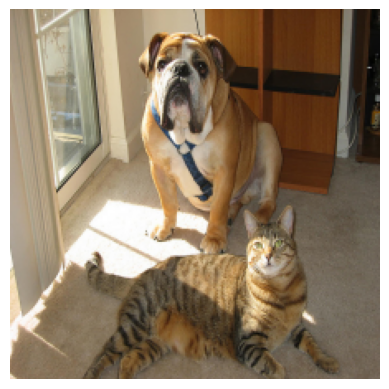

In [4]:
utils.draw_image(img)

In [42]:
N = 5000      # number of masks (start small)
s = 7        # grid size
p = 0.1       # activation probability

test = RISE(model, img_x)
test.generate_masks(N, s, p)
#test.load_masks()

Generating filters: 100%|██████████| 5000/5000 [00:01<00:00, 3177.63it/s]


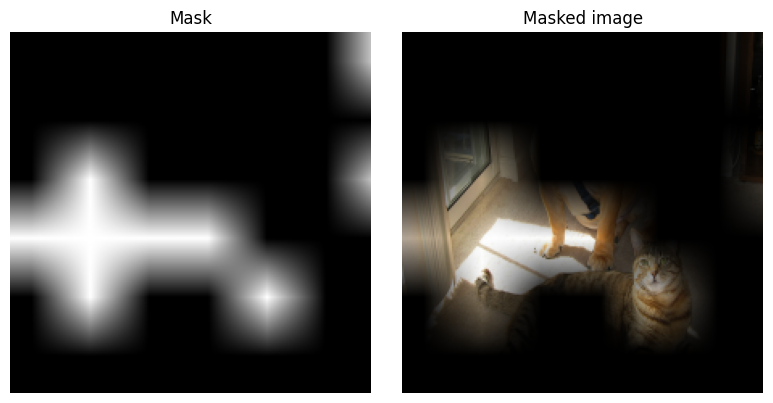

In [37]:
random_index = np.random.randint(N)
utils.draw_masked_image(img, test.masks[random_index])

## default RISE

In [43]:
topk = utils.get_topk_predictions(model, img_x, weights, k=5)
topk

[{'class_id': 243, 'class_name': 'bull mastiff', 'logit': 6.158624649047852},
 {'class_id': 281, 'class_name': 'tabby', 'logit': 3.580155611038208},
 {'class_id': 242, 'class_name': 'boxer', 'logit': 3.4773542881011963},
 {'class_id': 180,
  'class_name': 'American Staffordshire terrier',
  'logit': 3.3361282348632812},
 {'class_id': 282, 'class_name': 'tiger cat', 'logit': 3.3233225345611572}]

In [44]:
sal = test(img_x)

Running model: 100%|██████████| 50/50 [00:07<00:00,  7.04it/s]


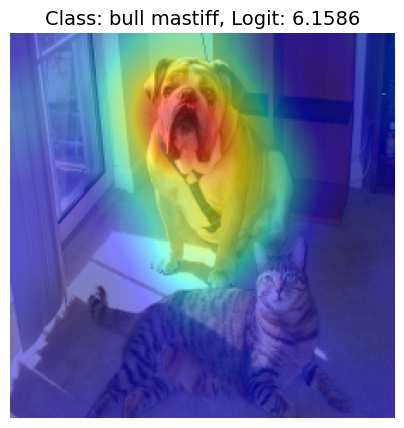

In [45]:
sal_map1 = utils.draw_saliency_overlay(img, sal, topk, k=0)

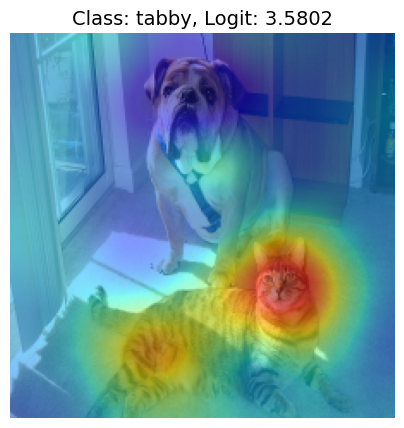

In [46]:
sal_map2 = utils.draw_saliency_overlay(img, sal, topk, k=1)


## Banzhaf Approx method

In [29]:
sal_bahnzafapprox, leftsum, rightsum = test(img_x, method="banzhaf-approx")

Running model: 100%|██████████| 20/20 [00:02<00:00,  9.32it/s]


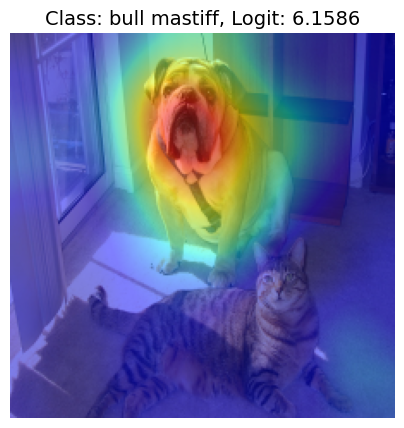

In [34]:
sal_bahnzafapprox_map1 = utils.draw_saliency_overlay(img, sal_bahnzafapprox, topk, k=0)


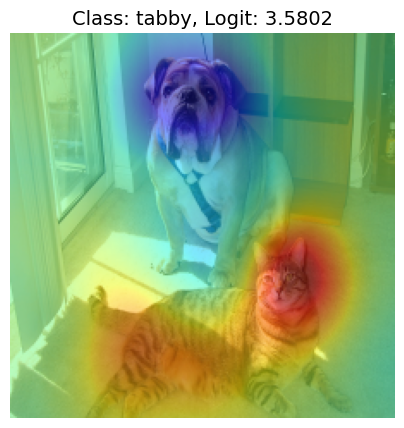

In [35]:
sal_bahnzafapprox_map2 = utils.draw_saliency_overlay(img, sal_bahnzafapprox, topk, k=1)


In [22]:
diff = sal_bahnzafapprox_map1 - sal_map1


print("min:", diff.min().item())
print("max:", diff.max().item())
print("mean:", diff.mean().item())
print("std:", diff.std().item())

for q in [0.01, 0.05, 0.5, 0.95, 0.99]:
    print(f"q{int(q*100):02d}:", torch.quantile(diff, q).item())

min: -0.8690603375434875
max: -0.5542442798614502
mean: -0.7612946033477783
std: 0.06294933706521988
q01: -0.8585957288742065
q05: -0.834504246711731
q50: -0.777104377746582
q95: -0.6173837184906006
q99: -0.5798910856246948


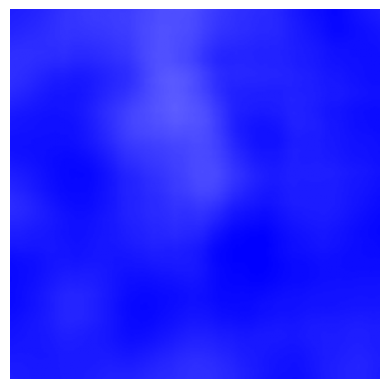

In [55]:
# plot diff
plt.axis("off")
plt.imshow(diff.cpu().numpy(), cmap="bwr", vmin=-diff.abs().max().item(), vmax=diff.abs().max().item())
plt.show()

## analysis of the RISE implementation


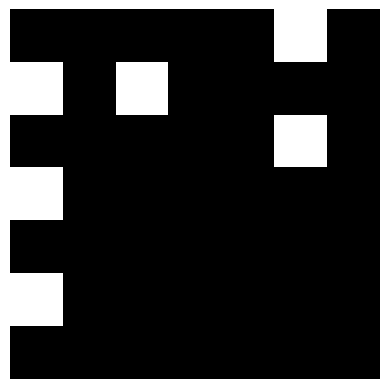

In [136]:
input_size = (img_x.shape[2], img_x.shape[3])
cell_size = np.ceil(np.array(input_size) / s).astype(int)

grids = np.random.rand(N, s, s) < p
grids = grids.astype('float32')

utils.draw_mask(grids[1])

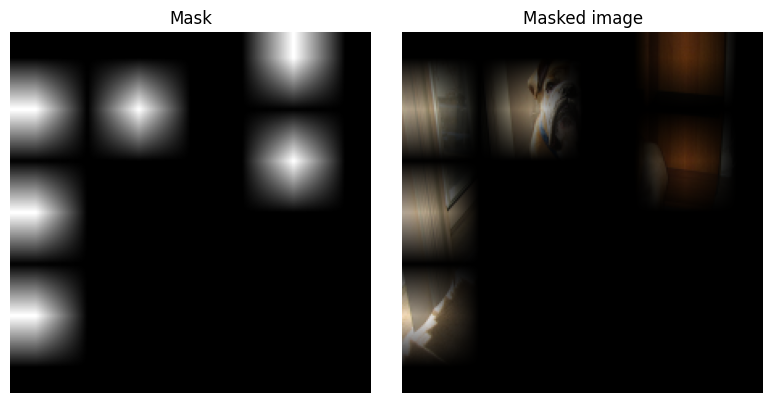

In [137]:
up_size = s * cell_size   

up_mask = resize_mask(grids[1], up_size)
utils.draw_masked_image(img, up_mask.reshape(-1, input_size[0], input_size[1]))

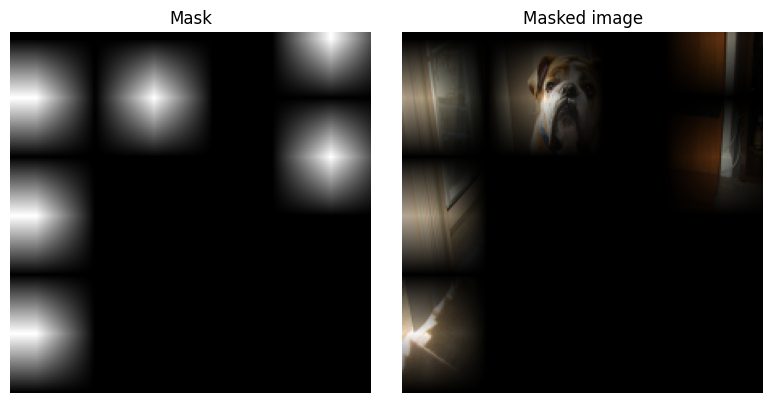

14 2


In [138]:
x = np.random.randint(0, cell_size[0])
y = np.random.randint(0, cell_size[1])

up_size = (s + 1) * cell_size   # +1 so we can shift grids
up_mask = resize_mask(grids[1], up_size, mode='bilinear')
mask = up_mask[x:x + input_size[0],y:y + input_size[1]]
utils.draw_masked_image(img, mask.reshape(-1, input_size[0], input_size[1]))

print(x,y)

# RISE Banzhaf

In [299]:

def resize_mask(mask, up_size, mode='bilinear'):
    mask_t = torch.from_numpy(mask).unsqueeze(0).unsqueeze(0)  # (1,1,s,s)
    if mode == 'bilinear':
        mask_up = F.interpolate(mask_t, size=up_size.tolist(), mode='bilinear', align_corners=False)
    else:
        mask_up = F.interpolate(mask_t, size=up_size.tolist(), mode=mode)

    return mask_up.squeeze()

class RISE_B(nn.Module):
    def __init__(self, model, x, gpu_batch=100, device=None):
        super(RISE_B, self).__init__()
        self.model = model
        _, _, H, W = x.shape
        self.input_size = (H, W)
        self.gpu_batch = gpu_batch
        self.device = device or torch.device("cuda" if torch.cuda.is_available() else "cpu")

    def generate_masks(self, N, s, p, mode='bilinear'):
        cell_size = np.ceil(np.array(self.input_size) / s).astype(int)
        self.up_size = (s + 1) * cell_size  # +1 so we can shift grids

        grids = np.random.rand(N, s, s) < p
        self.grids = grids.astype("float32")

        shifts = []
        for _ in range(N):
            x_shift = np.random.randint(0, cell_size[0])
            y_shift = np.random.randint(0, cell_size[1])
            shifts.append((x_shift, y_shift))

        self.N = N
        self.s = s
        self.p = p
        self.shifts = shifts
        self.mode = mode

    def render_grid(self, grid_np, shift):
        up_mask = resize_mask(grid_np, self.up_size, mode=self.mode)

        x, y = shift
        cropped = up_mask[x:x + self.input_size[0], y:y + self.input_size[1]]

        return cropped.unsqueeze(0).unsqueeze(0)
    
    
    def forward(self, x):
        with torch.no_grad():
                num_classes = self.model(x).shape[1]

        H, W = self.input_size
        saliency = torch.zeros(num_classes, H, W, device=self.device)
        counter = 0

        for idx in range(self.N):
            
            grid = self.grids[idx]
            shift = self.shifts[idx]

            base_mask = self.render_grid(grid, shift).to(self.device)       # (1,1,H,W)
            with torch.no_grad():
                baseline = self.model(x * base_mask)                    # (1,num_classes)
                counter += 1
                
            zero_positions = np.argwhere(grid == 0)
            if len(zero_positions) == 0:
                continue
            
            # calculate flipped masks for all zero positions
            flipped_masks = []

            for (i, j) in zero_positions:
                flipped_grid = grid.copy()
                flipped_grid[i, j] = 1

                mask = self.render_grid(flipped_grid, shift)
                flipped_masks.append(mask)

            # Stack into batch
            flipped_masks = torch.cat(flipped_masks, dim=0).to(self.device)     # (num_flips,1,H,W)

            # Batch forward
            with torch.no_grad():
                outputs = self.model(x * flipped_masks)
                counter += flipped_masks.shape[0]

            diffs = outputs - baseline       # (num_flips, num_classes)

            for idx, diff_vec in enumerate(diffs):
                delta_mask = flipped_masks[idx] - base_mask   # (1,1,H,W)
                delta_mask = delta_mask.squeeze(0)            # (1,H,W)

                saliency += diff_vec.view(-1, 1, 1) * delta_mask        # (num_classes,H,W)

            
        print("Total forward passes:", counter)
        return saliency / (self.N * (1 - self.p))

In [300]:
test_b = RISE_B(model, img_x)

In [312]:
test_b.generate_masks(100, 9, 0.5)

In [313]:
sal = test_b.forward(img_x)

Total forward passes: 4179


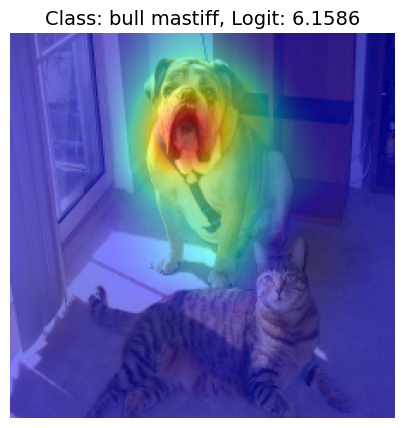

In [320]:
sal_map = utils.draw_saliency_overlay(img, sal, topk, k=0)

## MNSIT DATA

In [493]:
from torchvision import datasets
from torch.utils.data import DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

transform = transforms.ToTensor()

train_dataset = datasets.MNIST("./data", train=True, download=True, transform=transform)
test_dataset  = datasets.MNIST("./data", train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=1000, shuffle=False)

In [494]:
class MNISTCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.fc1   = nn.Linear(64 * 7 * 7, 128)
        self.fc2   = nn.Linear(128, 10)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.max_pool2d(x, 2)      # 14x14
        x = F.relu(self.conv2(x))
        x = F.max_pool2d(x, 2)      # 7x7
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        return self.fc2(x)

In [495]:
model = MNISTCNN().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

epochs = 3

for epoch in range(epochs):
    model.train()
    total_loss = 0
    
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        
        optimizer.zero_grad()
        output = model(x)
        loss = criterion(output, y)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    print(f"Epoch {epoch+1}, Loss: {total_loss/len(train_loader):.4f}")

Epoch 1, Loss: 0.2398
Epoch 2, Loss: 0.0587
Epoch 3, Loss: 0.0399


In [496]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for x, y in test_loader:
        x, y = x.to(device), y.to(device)
        output = model(x)
        preds = output.argmax(dim=1)
        correct += (preds == y).sum().item()
        total += y.size(0)

print("Test Accuracy:", correct / total)

Test Accuracy: 0.9859


In [497]:
examples = []

with torch.no_grad():
    for x, y in test_loader:
        x, y = x.to(device), y.to(device)
        output = model(x)
        preds = output.argmax(dim=1)
        
        for i in range(len(x)):
            if preds[i] == y[i]:
                examples.append((x[i:i+1], y[i:i+1]))
            if len(examples) == 5:
                break
        if len(examples) == 5:
            break

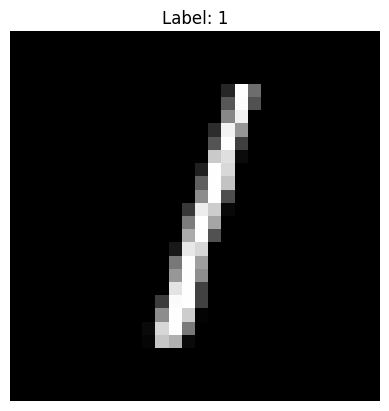

In [536]:
i = 2
img_x, label = examples[i]

plt.imshow(img_x.squeeze().cpu(), cmap="gray")
plt.title(f"Label: {label.item()}")
plt.axis("off")
plt.show()

In [537]:
test_b = RISE_B(model, img_x)
test_b.generate_masks(N=10, s=28, p=0.5)

In [538]:
sal = test_b.forward(img_x)

Total forward passes: 4013


In [475]:
def draw_saliency_overlay_mnist(img, saliency_maps, class_id):
    # Image
    if torch.is_tensor(img):
        img = img.cpu().squeeze().numpy()
    
    # Saliency
    sal = saliency_maps[class_id]
    if torch.is_tensor(sal):
        sal = sal.cpu().numpy()
    
    plt.figure(figsize=(4,4))
    plt.imshow(img, cmap="gray")
    plt.imshow(sal, cmap="jet", alpha=0.5)
    plt.title(f"Class {class_id}")
    plt.axis("off")
    plt.show()

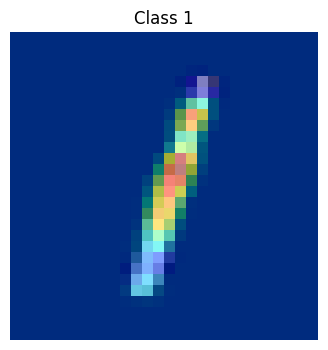

In [539]:
draw_saliency_overlay_mnist(img_x, sal, class_id=1)

In [466]:
test_b_rise = RISE(model, img_x)
test_b_rise.generate_masks(N=7000, s=28, p=0.1)

Generating filters: 100%|██████████| 7000/7000 [00:00<00:00, 35737.87it/s]


In [467]:
sal_rise = test_b_rise.forward(img_x)

Running model: 100%|██████████| 70/70 [00:00<00:00, 1848.22it/s]


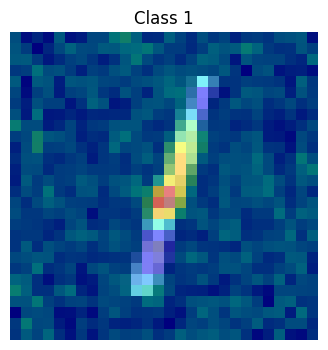

In [468]:
draw_saliency_overlay_mnist(img_x, sal_rise, class_id=1)

## prens

In [444]:
img_path = IMAGES / "prens.png"
img, img_x = utils.load_image(img_path, device, preprocess)

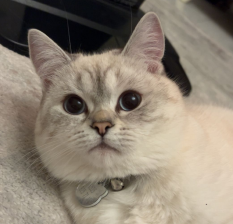

In [445]:
img

In [446]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load pretrained weights
weights = ResNet50_Weights.DEFAULT

# Build model
model = models.resnet50(weights=weights)

# Do not add softmax for probability output (better for banzhaf since we look at marginal contribution)
#model = nn.Sequential(
#    base_model,
#   nn.Softmax(dim=1)
#)

model = model.to(device)
model.eval()

# Preprocessing transform
preprocess = weights.transforms()

In [447]:
test_c = RISE(model, img_x)
test_c.generate_masks(N=4000, s=7, p=0.1)

Generating filters: 100%|██████████| 4000/4000 [00:01<00:00, 3077.32it/s]


In [448]:
sal = test_c.forward(img_x)

Running model: 100%|██████████| 40/40 [00:20<00:00,  1.97it/s]


In [449]:
topk = utils.get_topk_predictions(model, img_x, weights, k=5)

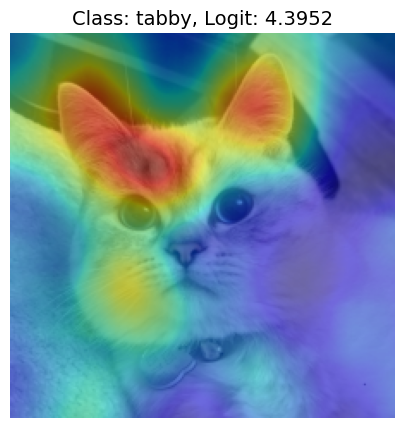

In [452]:
sal_map = utils.draw_saliency_overlay(img, sal, topk=topk, k=2)

## Exact Banzhaf

In [ ]:
def build_supergrid_mask(mask_vec, s=2, H=28, W=28):
    block_h = H // s
    block_w = W // s

    mask = torch.zeros(1, 1, H, W)

    for i in range(s * s):
        if mask_vec[i] == 1:
            r = i // s
            c = i % s

            mask[:, :, 
                 r*block_h:(r+1)*block_h,
                 c*block_w:(c+1)*block_w] = 1

    return mask

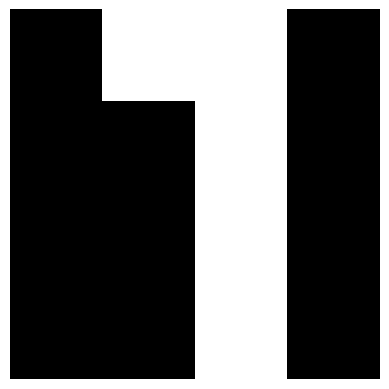

In [555]:
utils.draw_mask(build_supergrid_mask(torch.tensor([0,1,1,0, 
                                                   0,0,1,0, 
                                                   0,0,1,0, 
                                                   0,0,1,0]), 4))

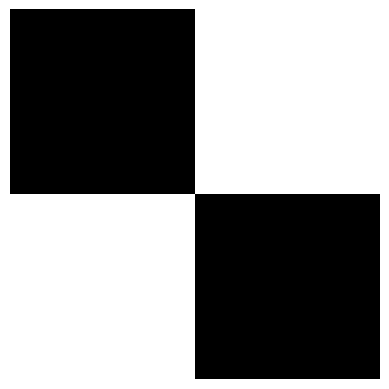

In [558]:
utils.draw_mask(build_supergrid_mask(torch.tensor([0,1, 
                                                   1,0]), 2))

In [559]:
def exact_banzhaf_supergrid(model, x, s):
    model.eval()
    device = x.device

    H, W = x.shape[-2:]
    d = s * s
    num_subsets = 2**d
    num_classes = model(x).shape[1]

    values = torch.zeros(num_subsets, num_classes, device=device)

    # Precompute v(S)
    with torch.no_grad():
        for mask_int in range(num_subsets):

            mask_vec = torch.tensor(
                [(mask_int >> j) & 1 for j in range(d)],
                device=device,
                dtype=torch.float32
            )

            mask_S = build_supergrid_mask(mask_vec, s, H, W).to(device)
            values[mask_int] = model(x * mask_S).squeeze(0)

    # Compute exact Banzhaf
    beta = torch.zeros(num_classes, d, device=device)

    for i in range(d):
        total = torch.zeros(num_classes, device=device)

        for mask_int in range(num_subsets):

            if (mask_int >> i) & 1:
                continue

            S = mask_int
            Si = mask_int | (1 << i)

            total += values[Si] - values[S]

        beta[:, i] = total / (2**(d-1))

    return beta.view(num_classes, s, s)

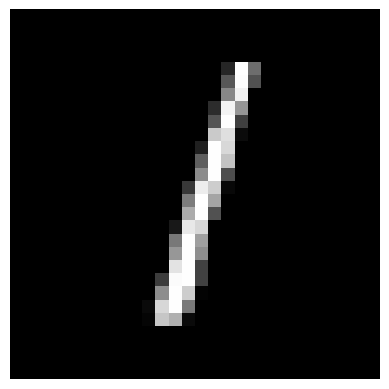

In [547]:
plt.imshow(img_x.cpu().squeeze().numpy(), cmap="gray")
plt.axis("off")
plt.show()

In [ ]:
model(img_x) # should be class 1 with high confidence, it is..

tensor([[-2.1583,  8.5105, -2.0952, -7.2607,  0.2347, -3.6329, -2.0857,  0.4116,
         -0.9055, -2.1338]], device='cuda:0', grad_fn=<AddmmBackward0>)

In [549]:
model(img_x).squeeze(0).shape

torch.Size([10])

In [596]:
beta = exact_banzhaf_supergrid(model, img_x, s=4)

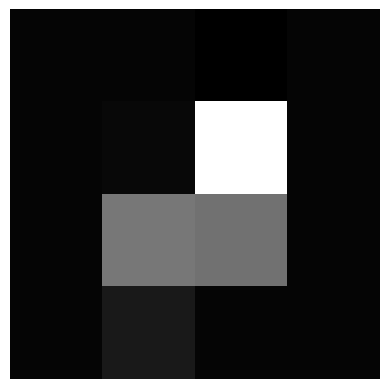

In [597]:
utils.draw_mask(beta[1])

In [599]:
# do banzhaf approx
test_d = RISE_B(model, img_x)
test_d.generate_masks(N=500, s=4, p=0.5)

In [600]:
sal = test_d.forward(img_x)

Total forward passes: 4536


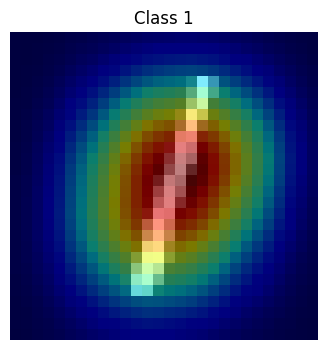

In [601]:
draw_saliency_overlay_mnist(img_x, sal, class_id=1)

In [605]:
test_d_rise = RISE(model, img_x)
test_d_rise.generate_masks(N=5000, s=4, p=0.1)

Generating filters: 100%|██████████| 5000/5000 [00:00<00:00, 33382.29it/s]


In [606]:
sal_rise = test_d_rise.forward(img_x)

Running model: 100%|██████████| 50/50 [00:00<00:00, 1094.82it/s]


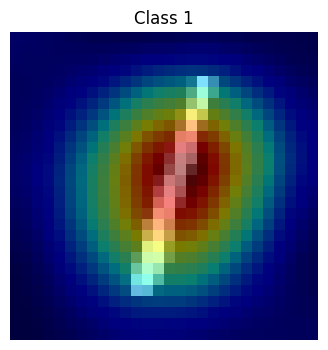

In [607]:
draw_saliency_overlay_mnist(img_x, sal_rise, class_id=1)